  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp313-cp313-win_amd64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Features used: 17
Feature list: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'balance_salary_ratio', 'products_per_tenure', 'is_zero_balance', 'age_x_inactive', 'credit_p

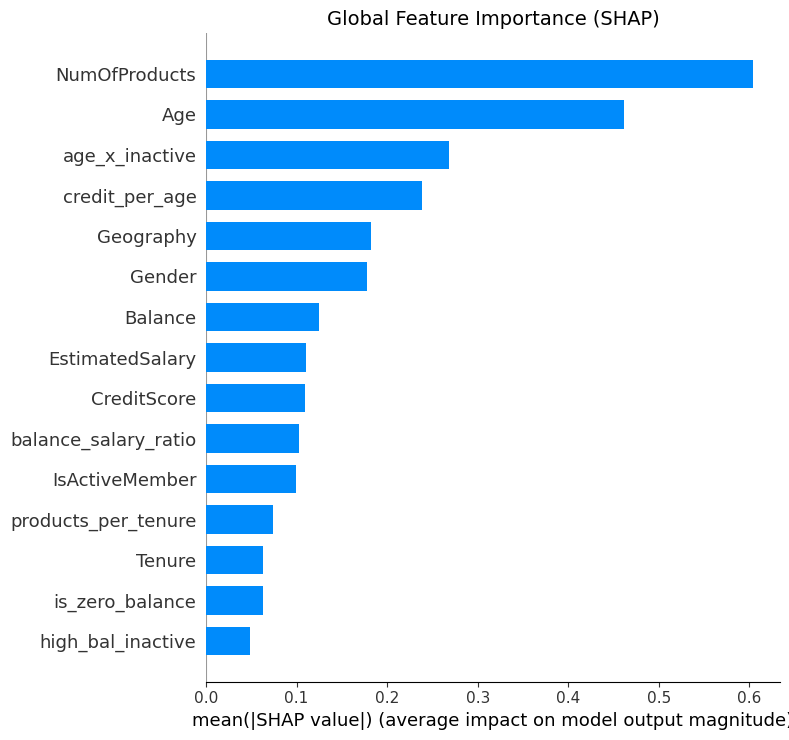

✅ Saved → docs/shap_global.png


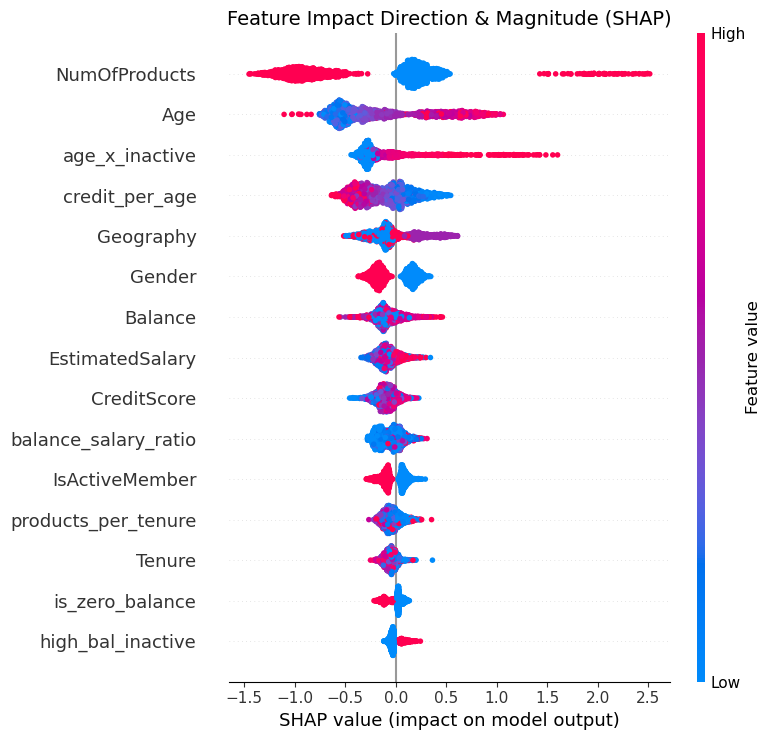

✅ Saved → docs/shap_beeswarm.png


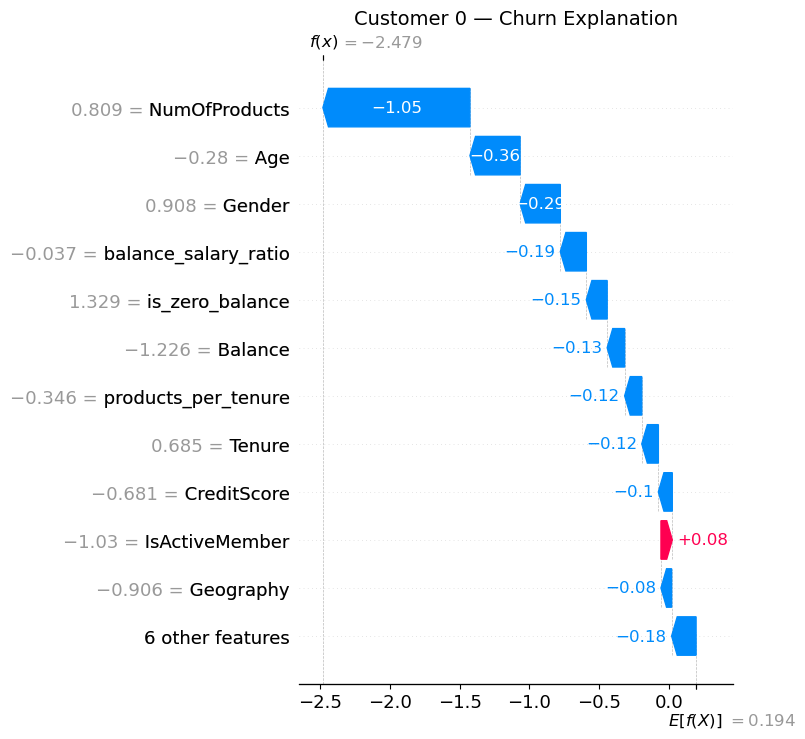

✅ Saved → docs/shap_customer_example.png

--- Top 10 Most Important Features ---
             Feature  Importance
       NumOfProducts    0.603524
                 Age    0.461746
      age_x_inactive    0.268478
      credit_per_age    0.238621
           Geography    0.181851
              Gender    0.178153
             Balance    0.125021
     EstimatedSalary    0.109936
         CreditScore    0.109241
balance_salary_ratio    0.102924

--- Customer 0 Explanation ---
Churn probability: 7.7%

Top factors pushing toward churn:

🔴 Pushing TOWARD churn:
       Feature  SHAP Value
IsActiveMember    0.081076

🟢 Pushing AWAY from churn:
          Feature  SHAP Value
          segment   -0.011402
        HasCrCard   -0.013546
   credit_per_age   -0.022522
high_bal_inactive   -0.024745
  EstimatedSalary   -0.043635

✅ All SHAP plots saved to docs/ folder!


In [2]:
import sys
!{sys.executable} -m pip install shap
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

# ─────────────────────────────────────
# STEP 1 — Setup & Load
# ─────────────────────────────────────
# Create docs folder if it doesn't exist
os.makedirs('../docs', exist_ok=True)

# Load model and scaler
model  = joblib.load('../src/best_model.pkl')
scaler = joblib.load('../src/scaler.pkl')

# ─────────────────────────────────────
# STEP 2 — Load and prepare data
# ─────────────────────────────────────
# Load enriched data
df = pd.read_csv('../data/bank_churn_with_predictions.csv')

# Define feature columns
feature_cols = [c for c in df.columns
                if c not in ['Exited', 'RowNumber', 
                             'CustomerId', 'Surname',
                             'clv', 'strategy',
                             'intervention_cost',
                             'retention_lift',
                             'expected_value',
                             'priority',
                             'churn_prob']]

print(f'Features used: {len(feature_cols)}')
print(f'Feature list: {feature_cols}')

# Split data same way as training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[feature_cols]
Y = df['Exited']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# Scale using loaded scaler
X_test_scaled  = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)

# Convert to dataframe for SHAP
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_cols)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)

print(f'Test samples for SHAP: {len(X_test_scaled_df)}')

# ─────────────────────────────────────
# STEP 3 — Create SHAP explainer
# ─────────────────────────────────────
print('\nCalculating SHAP values (this may take a moment)...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled_df)
print('✅ SHAP values calculated!')

# ─────────────────────────────────────
# STEP 4 — Global Feature Importance (Bar)
# ─────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test_scaled_df,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Global Feature Importance (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → docs/shap_global.png')

# ─────────────────────────────────────
# STEP 5 — Beeswarm Plot
# ─────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    max_display=15,
    show=False
)
plt.title('Feature Impact Direction & Magnitude (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → docs/shap_beeswarm.png')

# ─────────────────────────────────────
# STEP 6 — Per customer waterfall plot
# ─────────────────────────────────────
# Show explanation for highest risk customer
highest_risk_idx = X_test_scaled_df.index[
    model.predict_proba(X_test_scaled)[:, 1].argmax()
]
customer_idx = 0  # change this to any index

explanation = shap.Explanation(
    values      = shap_values[customer_idx],
    base_values = explainer.expected_value,
    data        = X_test_scaled_df.iloc[customer_idx],
    feature_names = feature_cols
)

plt.figure()
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f'Customer {customer_idx} — Churn Explanation', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/shap_customer_example.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → docs/shap_customer_example.png')

# ─────────────────────────────────────
# STEP 7 — Top features summary
# ─────────────────────────────────────
# Calculate mean absolute SHAP values
feature_importance = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('Importance', ascending=False)

print('\n--- Top 10 Most Important Features ---')
print(feature_importance.head(10).to_string(index=False))

# ─────────────────────────────────────
# STEP 8 — Force plot for one customer
# ─────────────────────────────────────
print(f'\n--- Customer {customer_idx} Explanation ---')
print(f'Churn probability: {model.predict_proba(X_test_scaled)[customer_idx][1]:.1%}')
print('\nTop factors pushing toward churn:')
customer_shap = pd.DataFrame({
    'Feature': feature_cols,
    'SHAP Value': shap_values[customer_idx]
}).sort_values('SHAP Value', ascending=False)

print('\n🔴 Pushing TOWARD churn:')
print(customer_shap[customer_shap['SHAP Value'] > 0].head(5).to_string(index=False))
print('\n🟢 Pushing AWAY from churn:')
print(customer_shap[customer_shap['SHAP Value'] < 0].head(5).to_string(index=False))

print('\n✅ All SHAP plots saved to docs/ folder!')


  Customer: LOWEST_RISK (index 1423)
  Churn Probability: 3.1%


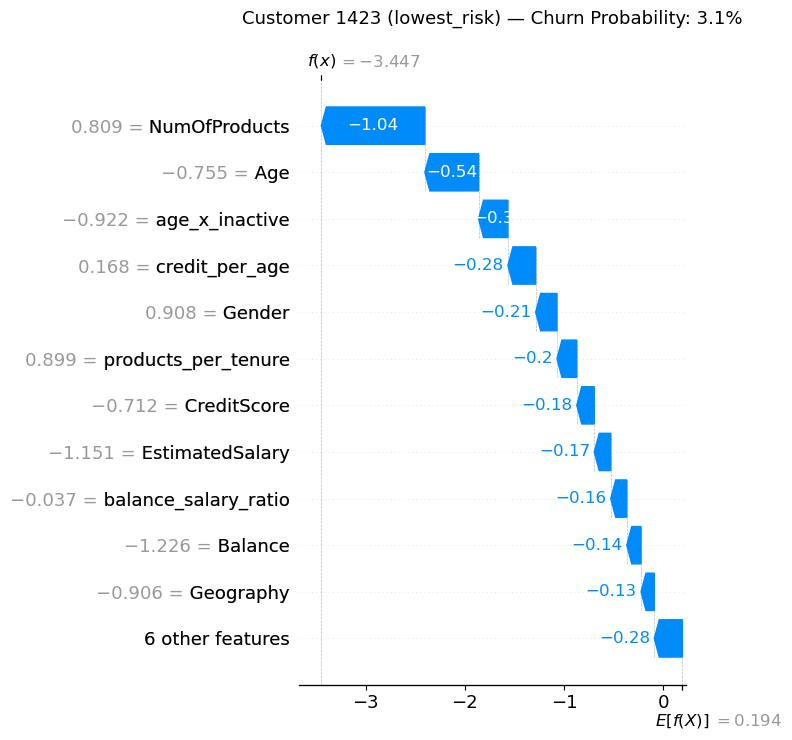

✅ Saved → docs/shap_lowest_risk.png

🔴 Top factors INCREASING churn risk:
   None — this customer is very safe!

🟢 Top factors DECREASING churn risk:
       Feature     Value  SHAP Impact
        Gender  0.907507    -0.214868
credit_per_age  0.167808    -0.279937
age_x_inactive -0.921682    -0.295838
           Age -0.754936    -0.541442
 NumOfProducts  0.808830    -1.043845

💼 Business Recommendation:
   ✅ SAFE — No Action needed

  Customer: HIGHEST_RISK (index 586)
  Churn Probability: 97.7%


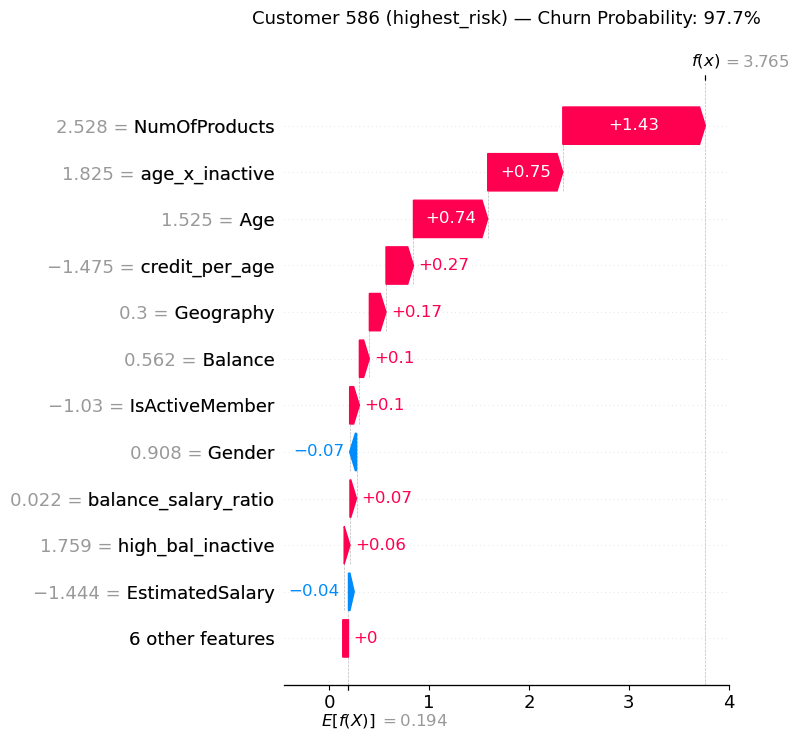

✅ Saved → docs/shap_highest_risk.png

🔴 Top factors INCREASING churn risk:
       Feature     Value  SHAP Impact
 NumOfProducts  2.527917     1.426424
age_x_inactive  1.825265     0.751586
           Age  1.525085     0.743147
credit_per_age -1.474659     0.274845
     Geography  0.300168     0.166463

🟢 Top factors DECREASING churn risk:
            Feature     Value  SHAP Impact
          HasCrCard  0.641042    -0.003744
        CreditScore -1.074149    -0.025566
products_per_tenure  0.699805    -0.028854
    EstimatedSalary -1.444380    -0.043068
             Gender  0.907507    -0.068837

💼 Business Recommendation:
   🚨 URGENT — Send Dedicated Relationship Manager

  Customer: MEDIAN_RISK (index 1597)
  Churn Probability: 23.2%


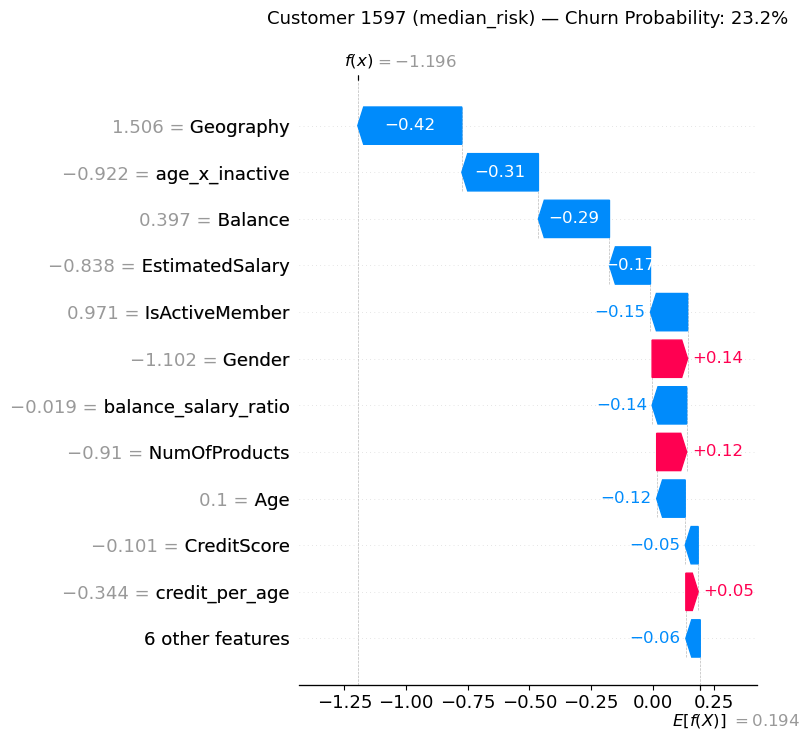

✅ Saved → docs/shap_median_risk.png

🔴 Top factors INCREASING churn risk:
        Feature     Value  SHAP Impact
         Gender -1.101919     0.144082
  NumOfProducts -0.910256     0.121754
 credit_per_age -0.343642     0.050171
is_zero_balance -0.752239     0.047674
         Tenure -0.350971     0.003821

🟢 Top factors DECREASING churn risk:
        Feature     Value  SHAP Impact
 IsActiveMember  0.970680    -0.150668
EstimatedSalary -0.837719    -0.166352
        Balance  0.396626    -0.288316
 age_x_inactive -0.921682    -0.310740
      Geography  1.506270    -0.422042

💼 Business Recommendation:
   🟢 LOW RISK — Standard Newsletter

  CUSTOM CUSTOMER LOOKUP


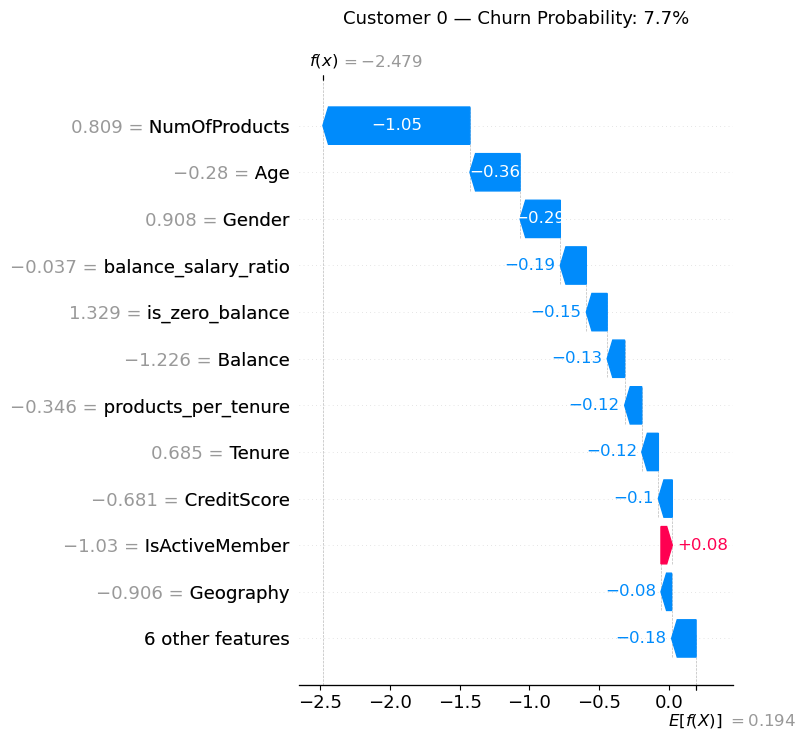


Customer 0 Summary:
Churn Probability: 7.7%
Risk Level: 🟢 LOW

✅ All customer explanations saved to docs/ folder!
💡 Change custom_idx to explain any customer you want!


In [3]:
# ─────────────────────────────────────
# SINGLE CUSTOMER EXPLANATION
# ─────────────────────────────────────

# IMPROVEMENT 1 — test multiple customers not just index 0
customers_to_explain = {
    'lowest_risk':  model.predict_proba(X_test_scaled)[:, 1].argmin(),
    'highest_risk': model.predict_proba(X_test_scaled)[:, 1].argmax(),
    'median_risk':  np.argsort(model.predict_proba(X_test_scaled)[:, 1])[len(X_test_scaled)//2]
}

for customer_name, customer_idx in customers_to_explain.items():
    
    # Get churn probability
    churn_prob = model.predict_proba(X_test_scaled)[customer_idx][1]
    
    print(f'\n{"="*55}')
    print(f'  Customer: {customer_name.upper()} (index {customer_idx})')
    print(f'  Churn Probability: {churn_prob:.1%}')
    print(f'{"="*55}')
    
    # ─────────────────────────────────────
    # STEP 1 — Build explanation object
    # ─────────────────────────────────────
    explanation = shap.Explanation(
        values        = shap_values[customer_idx],
        base_values   = explainer.expected_value,
        data          = X_test_scaled_df.iloc[customer_idx],
        feature_names = feature_cols
    )
    
    # ─────────────────────────────────────
    # STEP 2 — Waterfall plot
    # ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.waterfall_plot(
        explanation, 
        max_display=12, 
        show=False
    )
    plt.title(
        f'Customer {customer_idx} ({customer_name}) — Churn Probability: {churn_prob:.1%}',
        fontsize=13,
        pad=20
    )
    plt.tight_layout()
    plt.savefig(
        f'../docs/shap_{customer_name}.png', 
        dpi=150, 
        bbox_inches='tight'
    )
    plt.show()
    print(f'✅ Saved → docs/shap_{customer_name}.png')
    
    # ─────────────────────────────────────
    # STEP 3 — Print factor breakdown
    # ─────────────────────────────────────
    customer_shap = pd.DataFrame({
        'Feature':     feature_cols,
        'Value':       X_test_scaled_df.iloc[customer_idx].values,
        'SHAP Impact': shap_values[customer_idx]
    }).sort_values('SHAP Impact', ascending=False)
    
    print(f'\n🔴 Top factors INCREASING churn risk:')
    pushing_up = customer_shap[customer_shap['SHAP Impact'] > 0]
    if len(pushing_up) > 0:
        print(pushing_up.head(5).to_string(index=False))
    else:
        print('   None — this customer is very safe!')
        
    print(f'\n🟢 Top factors DECREASING churn risk:')
    pushing_down = customer_shap[customer_shap['SHAP Impact'] < 0]
    if len(pushing_down) > 0:
        print(pushing_down.tail(5).to_string(index=False))
    else:
        print('   None — this customer is very high risk!')
    
    # ─────────────────────────────────────
    # STEP 4 — Business recommendation
    # ─────────────────────────────────────
    print(f'\n💼 Business Recommendation:')
    if churn_prob >= 0.70:
        print(f'   🚨 URGENT — Send Dedicated Relationship Manager')
    elif churn_prob >= 0.60:
        print(f'   ⚠️  HIGH RISK — Priority Call + Exclusive Offer')
    elif churn_prob >= 0.45:
        print(f'   🟡 MODERATE — Email + Fee Waiver')
    elif churn_prob >= 0.40:
        print(f'   🟡 MODERATE — Loyalty Points Bonus')
    elif churn_prob >= 0.20:
        print(f'   🟢 LOW RISK — Standard Newsletter')
    else:
        print(f'   ✅ SAFE — No Action needed')

# ─────────────────────────────────────
# STEP 5 — Custom customer lookup
# ─────────────────────────────────────
print(f'\n{"="*55}')
print('  CUSTOM CUSTOMER LOOKUP')
print(f'{"="*55}')

# Change this index to explain any specific customer
custom_idx = 0

churn_prob  = model.predict_proba(X_test_scaled)[custom_idx][1]
explanation = shap.Explanation(
    values        = shap_values[custom_idx],
    base_values   = explainer.expected_value,
    data          = X_test_scaled_df.iloc[custom_idx],
    feature_names = feature_cols
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(
    f'Customer {custom_idx} — Churn Probability: {churn_prob:.1%}',
    fontsize=13,
    pad=20
)
plt.tight_layout()
plt.savefig('../docs/shap_custom_customer.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nCustomer {custom_idx} Summary:')
print(f'Churn Probability: {churn_prob:.1%}')
print(f'Risk Level: {"🔴 HIGH" if churn_prob > 0.6 else "🟡 MEDIUM" if churn_prob > 0.3 else "🟢 LOW"}')
print('\n✅ All customer explanations saved to docs/ folder!')
print('💡 Change custom_idx to explain any customer you want!')